# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Unificar datos provenientes de 3 fuentes una misma estructura.|Cómo asegurar que los datos de distintas fuentes tengan un formato consistente para poder integrarlos en un único DataFrame.|En el caso del audio, crear una función wrapper para adaptar su salida al formato del resto.|apliqué una función wrapper únicamente para el audio, porque su formato original difería del de las noticias web y el JSON.| Descarté usar el título del video como identificador en audio y opté por usar la URL para mantener consistencia con las fuentes web|Que no siempre es necesario rehacer todo el código para unificar datos: muchas veces alcanza con adaptar la fuente que es diferente.|
| **Parte 2** |Extraer y analizar entidades, verbos y estructuras lingüísticas del corpus. |Cómo mejorar la calidad de las entidades detectadas cuando aparecen duplicadas o inconsistentes (ej: “Huang” vs “Jensen Huang”).|Sugirió aplicar una normalización posterior al análisis (reglas o diccionario) para unificar variantes de una misma entidad.|Implementé una normalización de entidades para unificar nombres (ej: “Huang” → “Jensen Huang”), evitando duplicaciones en los conteos.|No modifiqué el modelo de spaCy ni entrené uno nuevo; opté por una solución simple basada en reglas por ser suficiente para el caso.|Que los modelos NLP cometen inconsistencias y es necesario un post-procesamiento para obtener resultados más confiables.|
| **Parte 3** |Diseñar visualizaciones claras para comunicar los resultados del análisis.|Cómo mejorar gráficos para que sean más claros y alineados con el principio de Data-Ink Ratio. |Sugirió simplificar los gráficos eliminando elementos innecesarios y priorizando visualizaciones como barplots o lollipop en lugar de opciones más decorativas. |Ajusté las visualizaciones para reducir ruido visual priorizando claridad en la lectura de datos.|No utilicé WordCloud, ya que no facilita la comparación ni aporta claridad para análisis orientado a decisiones.|Que el Data-Ink Ratio ayuda a tomar decisiones de diseño más efectivas.|
| **Parte 4** |Integrar todas las etapas del proyecto en una clase única.|Integrar todas las etapas del proyecto en una clase única.|Sugirió dividir el flujo en etapas (extracción, unificación, análisis y exportación)|La organización por etapas, porque hace el código más claro y ordenado.|Llamadas desordenadas o redundantes, que generaban errores|Que la organización del flujo y la consistencia en nombres son clave para que el pipeline funcione.|
| **Parte 5** |Diseñar una interfaz interactiva para explorar los resultados del análisis.|Diseñar una interfaz interactiva para explorar los resultados del análisis.|Cómo estructurar una interfaz con pestañas que separe métricas generales y exploración de entidades.|Sugirió usar un layout con Tabs para organizar la información y conectar funciones del backend con la interfaz.|Interfaces en una sola pantalla, ya que resultaban más confusas y sobrecargadas.|Que la organización visual y la interacción son clave para hacer útil el análisis de datos. |

**Ajustes de diseño y simplificación del pipeline**
- Durante la evolución del proyecto se decidió eliminar el uso de datos en formato JSON como fuente de entrada, ya que resultaba redundante respecto a las otras fuentes (web y audio) y no aportaba valor adicional al análisis.
- En paralelo, se realizó una mejora en la interfaz de usuario desarrollada con Gradio. Originalmente, las entidades se mostraban en formato JSON, lo que generaba una visualización poco clara y difícil de interpretar.
Se reemplazó esta salida por una representación en tablas

In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Juli\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')


In [2]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## hipotesis del trabajo
¿Cómo evolucionaron las palabras con las que los medios hispanohablantes describieron el impacto de la IA en el empleo entre noviembre de 2022 y abril de 2026?
- se busco fuentes desde 2023 hasta 2026  
###ejemplos de preguntas de investigacion

- ¿Qué verbos específicos dominaban en 2022? ¿"reemplazar", "eliminar", "desaparecer"? ¿O era más "amenazar", "afectar", "impactar"?
- ¿Qué entidades (personas, organizaciones) se mencionan más en cada época? En 2022 probablemente OpenAI y ChatGPT. ¿En 2026 qué organizaciones dominan?

## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame.
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [3]:
def extraer_noticias_web(urls):
    import trafilatura

    noticias = []

    for url in urls:
        try:
            # 1. Descargar con trafilatura
            downloaded = trafilatura.fetch_url(url)

            # 2. Extraer texto
            texto = trafilatura.extract(downloaded)

            if texto:
                noticias.append({
                    "titulo_o_fuente": url,
                    "texto": texto,
                    "origen": "web"
                })
            else:
                print(f"No se pudo extraer texto de: {url}")

        except Exception as e:
            print(f"Error con {url}: {e}")

    return noticias

In [4]:
urls = [
    "https://www.infobae.com/tecno/2023/07/31/ceo-de-openai-creador-de-chatgpt-no-sabe-que-empleos-desaparecerian-por-la-inteligencia-artificial/",
    "https://www.infobae.com/economia/2023/05/08/preocupante-pronostico-la-inteligencia-artificial-pondra-en-jaque-a-casi-el-25-de-los-puestos-de-trabajo-en-todo-el-mundo/",
    "https://www.infobae.com/estados-unidos/2023/11/03/elon-musk-advirtio-que-la-inteligencia-artificial-dejara-a-los-humanos-sin-trabajo/",
    "https://www.infobae.com/tecno/2023/11/30/chatgpt-de-openai-cumple-un-ano-y-este-ha-sido-su-impacto-global/",
    "https://www.infobae.com/tecno/2024/04/29/la-ia-y-los-robots-generan-panico-en-el-mundo-laboral-por-la-perdida-de-empleos/",
    "https://www.infobae.com/tecno/2025/07/25/el-mensaje-de-jensen-huang-ceo-de-nvidia-si-no-usas-ia-perderas-tu-trabajo-frente-a-quien-si-la-use/",
    "https://www.infobae.com/opinion/2025/05/28/el-impacto-de-la-inteligencia-artificial-en-el-empleo-que-trabajos-podremos-hacer-los-humanos/",
    "https://www.infobae.com/tecno/2025/12/17/jensen-huang-despejo-el-miedo-de-los-que-temen-perder-el-empleo-la-inteligencia-artificial-transforma-tareas-no-elimina-profesiones/",
    "https://www.infobae.com/tecno/2026/03/24/ni-la-ia-mas-avanzada-podra-fundar-una-nueva-nvidia-la-leccion-del-lider-de-la-empresa-mas-valiosa-del-planeta/",
    "https://www.infobae.com/estados-unidos/2026/04/10/la-inteligencia-artificial-ya-reemplaza-tareas-en-el-20-de-empleados-a-tiempo-completo-en-eeuu/",
]

datos_web = extraer_noticias_web(urls)

import pandas as pd
df_web = pd.DataFrame(datos_web)

df_web.head()

,titulo_o_fuente,texto,origen
0,https://www.infobae.com/tecno/2023/07/31/ceo-d...,Uno de los miedos comunes con respecto al desa...,web
1,https://www.infobae.com/economia/2023/05/08/pr...,El mundo del trabajo experimentará grandes cam...,web
2,https://www.infobae.com/estados-unidos/2023/11...,"Elon Musk, CEO de Tesla y SpaceX, predijo que ...",web
3,https://www.infobae.com/tecno/2023/11/30/chatg...,ChatGPT es un modelo de IA generativa que desd...,web
4,https://www.infobae.com/tecno/2024/04/29/la-ia...,La revolución tecnológica está transformando e...,web


In [5]:
def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto
    import json
    import os
    import re
    import shutil
    import whisper
    import yt_dlp

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = info["title"]
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")

    print(f"Audio descargado: {titulo} ({duracion} segundos)")

    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    print(f"Transcripcion completa: {len(resultado_local['segments'])} segmentos")

    nombre_base = sanitizar(audio_generado)
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as archivo_txt:
        archivo_txt.write(resultado_local["text"])

    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as archivo_json:
        json.dump(
            {
                "fuente": url,
                "titulo": titulo,
                "duracion_segundos": duracion,
                "idioma": resultado_local["language"],
                "texto": resultado_local["text"],
                "segmentos": [
                    {"inicio": segmento["start"], "fin": segmento["end"], "texto": segmento["text"].strip()}
                    for segmento in resultado_local["segments"]
                ],
            },
            archivo_json,
            ensure_ascii=False,
            indent=2,
        )

    return {
        "titulo": titulo,
        "duracion": duracion,
        "texto": resultado_local["text"],
        "segmentos": resultado_local["segments"],
        "archivos_generados": [audio_generado, ruta_txt, ruta_json],
    }


# Uso sugerido:
# corpus = youtube_a_texto("https://www.youtube.com/watch?v=yX2tPSjBoeU")
# print(corpus["texto"][:500])


In [6]:
def transcribir_audio_youtube(url_video):
    try:
        resultado = youtube_a_texto(url_video)

        return [{
            "titulo_o_fuente": url_video,   # 👈 ahora usamos la URL
            "texto": resultado["texto"],
            "origen": "audio",
        }]

    except Exception as e:
        print(f"Error procesando audio: {e}")
        return []

In [7]:
# prueba
url = "https://youtu.be/6ie3OUPcCqs?si=_ZIGpXrJNnvBNIQo"

datos_audio = transcribir_audio_youtube(url)

import pandas as pd
df_audio = pd.DataFrame(datos_audio)

df_audio.head()

[youtube] Extracting URL: https://youtu.be/6ie3OUPcCqs?si=_ZIGpXrJNnvBNIQo
[youtube] 6ie3OUPcCqs: Downloading webpage


[youtube] 6ie3OUPcCqs: Downloading android vr player API JSON
[info] 6ie3OUPcCqs: Downloading 1 format(s): 251
[download] Destination: corpus\El 50% del empleo será sustituido por IA antes de 2030.webm
[download] 100% of    8.79MiB in 00:00:00 at 22.58MiB/s    
[ExtractAudio] Destination: corpus\El 50% del empleo será sustituido por IA antes de 2030.mp3
Deleting original file corpus\El 50% del empleo será sustituido por IA antes de 2030.webm (pass -k to keep)
Audio descargado: El 50% del empleo será sustituido por IA antes de 2030 (572 segundos)
Transcripcion completa: 210 segmentos


,titulo_o_fuente,texto,origen
0,https://youtu.be/6ie3OUPcCqs?si=_ZIGpXrJNnvBNIQo,Imagina llegar mañana a la oficina y que la m...,audio


In [8]:
def unificar_corpus(datos_web, datos_audio):
    import pandas as pd

    try:
        # Convertimos a DataFrame si hace falta
        df_web = pd.DataFrame(datos_web)
        df_audio = pd.DataFrame(datos_audio)

        # Unimos todo
        df_unificado = pd.concat([df_web, df_audio], ignore_index=True)

        return df_unificado

    except Exception as e:
        print(f"Error unificando corpus: {e}")
        return pd.DataFrame()

In [9]:
#prueba
df_corpus = unificar_corpus(df_web, df_audio)

df_corpus.head(11)

,titulo_o_fuente,texto,origen
0,https://www.infobae.com/tecno/2023/07/31/ceo-d...,Uno de los miedos comunes con respecto al desa...,web
1,https://www.infobae.com/economia/2023/05/08/pr...,El mundo del trabajo experimentará grandes cam...,web
2,https://www.infobae.com/estados-unidos/2023/11...,"Elon Musk, CEO de Tesla y SpaceX, predijo que ...",web
3,https://www.infobae.com/tecno/2023/11/30/chatg...,ChatGPT es un modelo de IA generativa que desd...,web
4,https://www.infobae.com/tecno/2024/04/29/la-ia...,La revolución tecnológica está transformando e...,web
5,https://www.infobae.com/tecno/2025/07/25/el-me...,"En los inicios de cada revolución tecnológica,...",web
6,https://www.infobae.com/opinion/2025/05/28/el-...,Duolingo tardó doce años en lanzar 100 cursos ...,web
7,https://www.infobae.com/tecno/2025/12/17/jense...,La irrupción de la inteligencia artificial gen...,web
8,https://www.infobae.com/tecno/2026/03/24/ni-la...,"El director ejecutivo de Nvidia, Jensen Huang,...",web
9,https://www.infobae.com/estados-unidos/2026/04...,La inteligencia artificial modificó procesos l...,web


In [10]:
df_corpus = df_corpus.reset_index(drop=True)

Esto esta pensando para hacer analisis por año mas adelante

In [11]:
import re

def extraer_anio(url):
    match = re.search(r"/(20\d{2})/", str(url))
    if match:
        return int(match.group(1))
    return None

In [12]:
df_corpus["anio"] = df_corpus["titulo_o_fuente"].apply(extraer_anio)

In [13]:
df_corpus.loc[df_corpus["origen"] == "audio", "anio"] = 2025

In [14]:
df_corpus

,titulo_o_fuente,texto,origen,anio
0,https://www.infobae.com/tecno/2023/07/31/ceo-d...,Uno de los miedos comunes con respecto al desa...,web,2023.0
1,https://www.infobae.com/economia/2023/05/08/pr...,El mundo del trabajo experimentará grandes cam...,web,2023.0
2,https://www.infobae.com/estados-unidos/2023/11...,"Elon Musk, CEO de Tesla y SpaceX, predijo que ...",web,2023.0
3,https://www.infobae.com/tecno/2023/11/30/chatg...,ChatGPT es un modelo de IA generativa que desd...,web,2023.0
4,https://www.infobae.com/tecno/2024/04/29/la-ia...,La revolución tecnológica está transformando e...,web,2024.0
5,https://www.infobae.com/tecno/2025/07/25/el-me...,"En los inicios de cada revolución tecnológica,...",web,2025.0
6,https://www.infobae.com/opinion/2025/05/28/el-...,Duolingo tardó doce años en lanzar 100 cursos ...,web,2025.0
7,https://www.infobae.com/tecno/2025/12/17/jense...,La irrupción de la inteligencia artificial gen...,web,2025.0
8,https://www.infobae.com/tecno/2026/03/24/ni-la...,"El director ejecutivo de Nvidia, Jensen Huang,...",web,2026.0
9,https://www.infobae.com/estados-unidos/2026/04...,La inteligencia artificial modificó procesos l...,web,2026.0


In [15]:
df_corpus["anio"].dtype

dtype('float64')

In [16]:
df_corpus["anio"] = df_corpus["anio"].astype("Int64")

In [17]:
df_corpus

,titulo_o_fuente,texto,origen,anio
0,https://www.infobae.com/tecno/2023/07/31/ceo-d...,Uno de los miedos comunes con respecto al desa...,web,2023
1,https://www.infobae.com/economia/2023/05/08/pr...,El mundo del trabajo experimentará grandes cam...,web,2023
2,https://www.infobae.com/estados-unidos/2023/11...,"Elon Musk, CEO de Tesla y SpaceX, predijo que ...",web,2023
3,https://www.infobae.com/tecno/2023/11/30/chatg...,ChatGPT es un modelo de IA generativa que desd...,web,2023
4,https://www.infobae.com/tecno/2024/04/29/la-ia...,La revolución tecnológica está transformando e...,web,2024
5,https://www.infobae.com/tecno/2025/07/25/el-me...,"En los inicios de cada revolución tecnológica,...",web,2025
6,https://www.infobae.com/opinion/2025/05/28/el-...,Duolingo tardó doce años en lanzar 100 cursos ...,web,2025
7,https://www.infobae.com/tecno/2025/12/17/jense...,La irrupción de la inteligencia artificial gen...,web,2025
8,https://www.infobae.com/tecno/2026/03/24/ni-la...,"El director ejecutivo de Nvidia, Jensen Huang,...",web,2026
9,https://www.infobae.com/estados-unidos/2026/04...,La inteligencia artificial modificó procesos l...,web,2026


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [18]:
class AnalizadorCorpus:

    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df

        print("Cargando modelo de lenguaje...")
        self.nlp = spacy.load(modelo_spacy)

        print("Procesando textos con spaCy...")
        self.df["doc"] = self.df["texto"].apply(self.nlp)

    # Normalización de nombres
    def normalizar_nombre(self, nombre):
        nombre_lower = nombre.lower()

        if "huang" in nombre_lower:
            return "Jensen Huang"
        elif "musk" in nombre_lower:
            return "Elon Musk"
        elif "altman" in nombre_lower:
            return "Sam Altman"

        return nombre.title()

    # Entidades (MEJORADO)
    def extraer_entidades(self):
        from collections import Counter

        entidades = {
            "PER": Counter(),
            "ORG": Counter(),
            "LOC": Counter()
        }

        for doc in self.df["doc"]:
            for ent in doc.ents:

                nombre = self.normalizar_nombre(ent.text)
                nombre_lower = nombre.lower()

                # Correcciones manuales
                if nombre_lower in ["tesla", "snapchat"]:
                    entidades["ORG"][nombre.title()] += 1
                    continue

                if "huang" in nombre_lower:
                    entidades["PER"]["Jensen Huang"] += 1
                    continue

                if "musk" in nombre_lower:
                    entidades["PER"]["Elon Musk"] += 1
                    continue

                if "altman" in nombre_lower:
                    entidades["PER"]["Sam Altman"] += 1
                    continue

                # Clasificación original
                if ent.label_ == "PER":
                    entidades["PER"][nombre] += 1

                elif ent.label_ == "ORG":
                    entidades["ORG"][nombre] += 1

                elif ent.label_ == "LOC":
                    # evitar personas en LOC
                    if any(x in nombre_lower for x in ["huang", "musk", "altman"]):
                        continue
                    entidades["LOC"][nombre] += 1

        return entidades

    # Verbos más frecuentes
    def extraer_verbos_principales(self, n=15):
        from collections import Counter

        contador = Counter()

        for doc in self.df["doc"]:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop:
                    contador[token.lemma_] += 1

        return contador.most_common(n)

    # Palabras clave
    def extraer_palabras_clave(self, n=20):
        from collections import Counter

        contador = Counter()

        for doc in self.df["doc"]:
            for token in doc:
                if (
                    token.pos_ in ["NOUN", "PROPN", "ADJ"]
                    and not token.is_stop
                    and not token.is_punct
                ):
                    contador[token.lemma_.lower()] += 1

        return contador.most_common(n)

    # Estadísticas
    def estadisticas_corpus(self):
        total_tokens = 0
        vocabulario = set()
        total_oraciones = 0

        for doc in self.df["doc"]:
            total_tokens += len(doc)
            vocabulario.update(
                [token.lemma_.lower() for token in doc if not token.is_punct]
            )
            total_oraciones += len(list(doc.sents))

        return {
            "total_palabras": total_tokens,
            "vocabulario_unico": len(vocabulario),
            "total_oraciones": total_oraciones
        }

In [19]:
analizador = AnalizadorCorpus(df_corpus)

entidades = analizador.extraer_entidades()

print(entidades["PER"].most_common(10))

Cargando modelo de lenguaje...
Procesando textos con spaCy...
[('Jensen Huang', 27), ('Sam Altman', 7), ('Elon Musk', 7), ('Goldman Sachs', 3), ('Geoffrey Hinton', 2), ('Rishi Sunak', 1), ('Alex Karp', 1), ('Palantir', 1), ('Steve Wozniak', 1), ('Dall-E.\nEl', 1)]


In [21]:
entidades = analizador.extraer_entidades()

for tipo in ["PER", "ORG", "LOC"]:
    print(f"\n--- {tipo} ---")
    for nombre, cantidad in entidades[tipo].most_common(12):
        print(nombre, "→", cantidad)


--- PER ---
Jensen Huang → 27
Sam Altman → 7
Elon Musk → 7
Goldman Sachs → 3
Geoffrey Hinton → 2
Rishi Sunak → 1
Alex Karp → 1
Palantir → 1
Steve Wozniak → 1
Dall-E.
El → 1
Figuras → 1
Claude → 1

--- ORG ---
Ia → 42
Nvidia → 18
Openai → 8
Wef → 4
Microsoft → 3
Google → 3
Foro Económico Mundial → 2
Tesla → 2
Bbc → 2
Sunak → 2
Institute For The Future Of Work → 2
Amazon → 2

--- LOC ---
En Estados Unidos → 6
Reino Unido → 2
Estados Unidos → 2
China → 2
Covid-19 → 1
Asia → 1
Oriente Medio → 1
Lancaster House → 1
Londres → 1
Bletchley Park → 1
Inglaterra → 1
Sunak → 1


In [22]:
verbos = analizador.extraer_verbos_principales()

for verbo, cantidad in verbos:
    print(verbo, "→", cantidad)

utilizar → 14
reemplazar → 11
llegar → 11
crear → 10
generar → 9
entender → 8
necesitar → 8
construir → 7
cambiar → 7
tener → 7
creer → 7
ofrecer → 7
surgir → 7
ver → 6
describir → 6


In [23]:
verbos = analizador.extraer_verbos_principales(5)  # top 5

# solo los lemas
lemas = [v[0] for v in verbos]

for doc in analizador.df["doc"]:
    for token in doc:
        if token.lemma_ in lemas and token.pos_ == "VERB":
            print(f"{token.lemma_:12} → {token.text}")

generar      → generar
reemplazar   → reemplazados
crear        → crearán
reemplazar   → reemplazados
reemplazar   → reemplazados
reemplazar   → reemplazados
crear        → creará
llegar       → llegarán
generar      → genere
utilizar     → utilizaban
generar      → genera
generar      → genera
reemplazar   → reemplazar
generar      → generan
generar      → generar
crear        → creará
crear        → creará
llegar       → llegar
llegar       → llegar
utilizar     → utilizar
reemplazar   → reemplazando
generar      → generar
crear        → crear
generar      → genera
llegar       → llegaría
utilizar     → utilizan
crear        → creamos
llegar       → llegan
crear        → crear
llegar       → lleguen
crear        → crear
utilizar     → utilizaran
crear        → crear
reemplazar   → reemplazado
reemplazar   → reemplazó
reemplazar   → reemplazadas
utilizar     → utiliza
utilizar     → utiliza
reemplazar   → reemplaza
utilizar     → utilizado
llegar       → llegar
llegar       → llegado


In [24]:
verbos = analizador.extraer_verbos_principales(5)
lemas = [v[0] for v in verbos]

for lema in lemas:
    print(f"\n {lema}")

    for doc in analizador.df["doc"]:
        for token in doc:
            if token.lemma_ == lema and token.pos_ == "VERB":
                print(" -", token.text)


 utilizar
 - utilizaban
 - utilizar
 - utilizan
 - utilizaran
 - utiliza
 - utiliza
 - utilizado
 - utilizando
 - utilizando
 - utiliza
 - utilizar
 - utilizar
 - utilizar
 - utilizar

 reemplazar
 - reemplazados
 - reemplazados
 - reemplazados
 - reemplazados
 - reemplazar
 - reemplazando
 - reemplazado
 - reemplazó
 - reemplazadas
 - reemplaza
 - reemplazar

 llegar
 - llegarán
 - llegar
 - llegar
 - llegaría
 - llegan
 - lleguen
 - llegar
 - llegado
 - llegar
 - llega
 - llegó
 - llega

 crear
 - crearán
 - creará
 - creará
 - creará
 - crear
 - creamos
 - crear
 - crear
 - crear
 - crear

 generar
 - generar
 - genere
 - genera
 - genera
 - generan
 - generar
 - generar
 - genera
 - generando


In [25]:
analizador = AnalizadorCorpus(df_corpus)

palabras = analizador.extraer_palabras_clave()

for palabra, cantidad in palabras:
    print(palabra, "→", cantidad)

Cargando modelo de lenguaje...
Procesando textos con spaCy...
inteligencia → 82
artificial → 81
ia → 78
empleo → 56
trabajo → 52
tecnología → 46
laboral → 41
tecnológico → 37
humano → 33
año → 31
huang → 27
tarea → 25
empresa → 24
impacto → 23
persona → 21
trabajador → 21
futuro → 20
modelo → 20
mundo → 20
cambio → 20


In [26]:
analizador = AnalizadorCorpus(df_corpus)

stats = analizador.estadisticas_corpus()

for k, v in stats.items():
    print(k, "→", v)

Cargando modelo de lenguaje...
Procesando textos con spaCy...
total_palabras → 10988
vocabulario_unico → 1927
total_oraciones → 386


prueba de formato texto vs audio

In [27]:
for sent in analizador.df["doc"][0].sents:
    print(sent)

Uno de los miedos comunes con respecto al desarrollo de la inteligencia artificial es la posibilidad de que las personas puedan perder sus trabajos en el futuro.
Aunque muchos expertos indican con optimismo que la IA no causará tales efectos, Sam Altman, CEO de OpenAI, no considera que esta postura sea realista y piensa que incluso estos programas pueden ser peligrosos.

Altman asegura que la posibilidad de que la inteligencia artificial elimine trabajos reales no es lejana y que, además, puede suponer un riesgo para la humanidad si sus capacidades no son controladas o al menos reguladas.
Este sería el motivo por el que el ejecutivo estaría interesado en generar consensos con respecto a la regulación o control de las funciones de estos programas.

Parte de este control (aunque pueda parecer contradictorio), aseguró durante una entrevista reciente con The Atlantic, es el acceso que se le ha dado a las personas a este modelo.

“Si hubiésemos construido esto (ChatGPT) por cinco años más e

In [28]:
for sent in analizador.df[analizador.df["origen"] == "audio"]["doc"].iloc[0].sents:
    print(sent)

 
Imagina llegar mañana a la oficina y que la mitad de la gente ya no esté.
Darío Amodei acaba de soltar la bomba.
El 50% de los trabajos junior de oficina desaparecerán antes de 2030 por la inteligencia artificial.
No es solo que Barack Obama haya reflexionado sobre ello en X. Time le dedica a una editorial titulada ¿Qué sucede cuando la IA reemplazo los trabajadores?
Y el New York Times ha sacado un artículo llamado el apocalipsis del empleo por la IA ha llegado para los recién graduados.
En televisión en Estados Unidos ya se está hablando de ello y las cifras asustan.
Vale, respira.
Esto no es el fin del mercado laboral como lo conocemos.
O quizás sí.
A esto de la inteligencia artificial le llamamos revolución tecnológica.
Igual no estaría además fijarnos en las anteriores por las que hemos pasado.
En el 1440 Gutenberg inventó la imprenta.
En una generación cayó el 90% del trabajo de los escribas y desplazó a una profesión entera.
Se tardaron unos 50 años en que la nueva industria e

Se observa que spaCy logra segmentar correctamente las oraciones en ambos casos, aunque presenta un mejor desempeño en las noticias web. Esto se debe a que los textos periodísticos cuentan con una estructura más clara, con uso consistente de puntuación, párrafos bien definidos y un lenguaje formal.

En contraste, el texto proveniente de la transcripción de audio presenta características propias del lenguaje oral, como frases más cortas, expresiones coloquiales (por ejemplo, “Vale, respira”) y cortes menos estructurados

segmentacion por años

In [29]:
for anio in sorted(df_corpus["anio"].dropna().unique()):
    print("\n====================")
    print("AÑO:", int(anio))
    print("====================")

    df_anio = df_corpus[df_corpus["anio"] == anio].copy()

    analizador_anio = AnalizadorCorpus(df_anio)
    entidades = analizador_anio.extraer_entidades()

    print("PER:", entidades["PER"].most_common(3))
    print("ORG:", entidades["ORG"].most_common(3))
    print("LOC:", entidades["LOC"].most_common(3))


AÑO: 2023
Cargando modelo de lenguaje...
Procesando textos con spaCy...
PER: [('Sam Altman', 7), ('Elon Musk', 7), ('Rishi Sunak', 1)]
ORG: [('Ia', 14), ('Openai', 8), ('Wef', 4)]
LOC: [('Reino Unido', 2), ('Covid-19', 1), ('Asia', 1)]

AÑO: 2024
Cargando modelo de lenguaje...
Procesando textos con spaCy...
PER: [('Techspot', 1), ('Magdalena Soffia', 1)]
ORG: [('Ia', 4), ('Institute For The Future Of Work', 2), ('Bmw', 1)]
LOC: []

AÑO: 2025
Cargando modelo de lenguaje...
Procesando textos con spaCy...
PER: [('Jensen Huang', 18), ('Heath Ahrens', 1), ('Escalar', 1)]
ORG: [('Nvidia', 11), ('Ia', 9), ('Mckinsey', 2)]
LOC: [('En Estados Unidos', 2), ('@Heathahrens', 1), ('Mercadolibre', 1)]

AÑO: 2026
Cargando modelo de lenguaje...
Procesando textos con spaCy...
PER: [('Jensen Huang', 9), ('Goldman Sachs', 3), ('Lex Fridman', 1)]
ORG: [('Ia', 15), ('Nvidia', 7), ('Nbc News', 2)]
LOC: [('En Estados Unidos', 4)]


In [30]:
for anio in sorted(df_corpus["anio"].dropna().unique()):
    print("\n====================")
    print("AÑO:", int(anio))
    print("====================")

    df_anio = df_corpus[df_corpus["anio"] == anio].copy()

    analizador_anio = AnalizadorCorpus(df_anio)
    verbos = analizador_anio.extraer_verbos_principales(5)

    print("VERBOS:", verbos)


AÑO: 2023
Cargando modelo de lenguaje...
Procesando textos con spaCy...
VERBOS: [('reemplazar', 5), ('generar', 4), ('suponer', 3), ('ver', 3), ('describir', 3)]

AÑO: 2024
Cargando modelo de lenguaje...
Procesando textos con spaCy...
VERBOS: [('generar', 2), ('representar', 2), ('incluir', 2), ('transformar', 1), ('introducir', 1)]

AÑO: 2025
Cargando modelo de lenguaje...
Procesando textos con spaCy...
VERBOS: [('llegar', 9), ('utilizar', 9), ('necesitar', 7), ('tardar', 6), ('pasar', 6)]

AÑO: 2026
Cargando modelo de lenguaje...
Procesando textos con spaCy...
VERBOS: [('utilizar', 4), ('reemplazar', 4), ('mostrar', 4), ('surgir', 3), ('crear', 3)]


> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [31]:
def visualizar_origen(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.close('all')

    conteo = df["origen"].value_counts()

    # detectar el máximo
    max_val = conteo.max()

    # asignar colores
    colores = [
        "#4C72B0" if v == max_val else "#D3D3D3"
        for v in conteo.values
    ]

    plt.figure()

    sns.barplot(
        x=conteo.values,
        y=conteo.index,
        palette=colores
    )

    plt.title("Cantidad de textos por origen")
    plt.xlabel("Cantidad")
    plt.ylabel("Origen")

    sns.despine()

    plt.show()

C:\Users\Juli\AppData\Local\Temp\ipykernel_4332\605232969.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


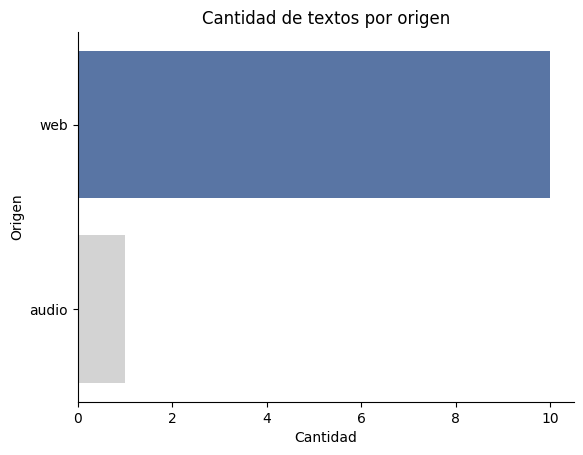

In [32]:
visualizar_origen(df_corpus)

In [33]:
def visualizar_palabras_clave_lollipop(palabras_clave):
    import matplotlib.pyplot as plt

    plt.close('all')

    palabras = [p[0] for p in palabras_clave][::-1]
    valores = [p[1] for p in palabras_clave][::-1]

    fig, ax = plt.subplots()

    # líneas finitas (menos tinta)
    ax.hlines(y=palabras, xmin=0, xmax=valores, linewidth=1)

    # puntos más chicos
    ax.plot(valores, palabras, "o", markersize=5)

    ax.set_title("Palabras clave más frecuentes")
    ax.set_xlabel("Frecuencia")

    # clave: limpiar ruido visual
    ax.spines[['top', 'right']].set_visible(False)

    plt.show()

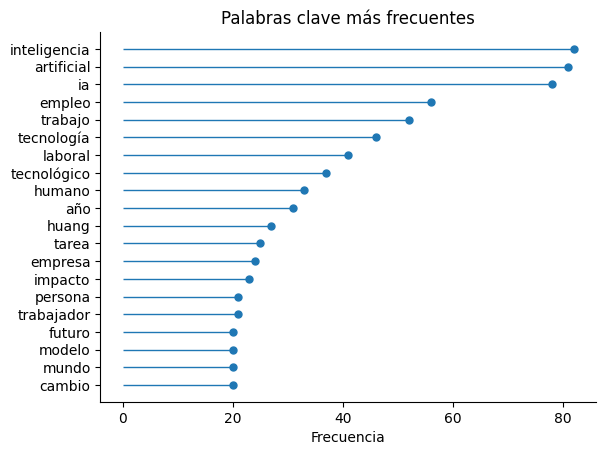

In [34]:
visualizar_palabras_clave_lollipop(palabras)

In [35]:
def visualizar_entidades_plotly_mejorado(entidades_dict):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    # Crear subplots (3 filas)
    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=("Personas (PER)", "Organizaciones (ORG)", "Lugares (LOC)")
    )

    tipos = ["PER", "ORG", "LOC"]

    for i, tipo in enumerate(tipos, start=1):
        top = entidades_dict[tipo].most_common(5)

        nombres = [x[0] for x in top]
        valores = [x[1] for x in top]

        fig.add_trace(
            go.Bar(
                x=valores,
                y=nombres,
                orientation='h',
                name=tipo
            ),
            row=i, col=1
        )

    fig.update_layout(
        height=800,
        title_text="Entidades más frecuentes por tipo",
        showlegend=False
    )

    return fig

In [36]:
fig = visualizar_entidades_plotly_mejorado(entidades)
fig.show()

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [37]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.df = None
        self.analizador = None

    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        print("Iniciando pipeline...")

        # =========================
        # 1. WEB
        # =========================
        datos_web = extraer_noticias_web(self.urls_web)

        # =========================
        # 2. AUDIO
        # =========================
        datos_audio = []
        if self.url_audio:
            datos_audio = transcribir_audio_youtube(self.url_audio)

        # =========================
        # 3. UNIFICACIÓN
        # =========================
        self.df = unificar_corpus(datos_web, datos_audio)

        # =========================
        # 4. LIMPIEZA
        # =========================
        self.df = self.df.drop_duplicates(subset=["texto"])

        # =========================
        # 5. ANÁLISIS (spaCy)
        # =========================
        self.analizador = AnalizadorCorpus(self.df)

        print("Pipeline ejecutado exitosamente.")

    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y métricas"""

        import json

        if self.df is None or self.analizador is None:
            print("Primero ejecutá el pipeline.")
            return

        # =========================
        # 1. CSV (sin columna doc)
        # =========================
        df_export = self.df.copy()

        if "doc" in df_export.columns:
            df_export = df_export.drop(columns=["doc"])

        df_export.to_csv(ruta_csv, index=False)

        # =========================
        # 2. JSON (estadísticas)
        # =========================
        entidades = self.analizador.extraer_entidades()
        verbos = self.analizador.extraer_verbos_principales()
        palabras = self.analizador.extraer_palabras_clave()
        stats = self.analizador.estadisticas_corpus()

        resultado = {
            "entidades": {k: dict(v) for k, v in entidades.items()},
            "verbos": dict(verbos),
            "palabras_clave": dict(palabras),
            "estadisticas": stats
        }

        with open(ruta_json, "w", encoding="utf-8") as f:
            json.dump(resultado, f, ensure_ascii=False, indent=4)

        print("Archivos exportados correctamente.")

In [38]:
pipe = PipelineMediatico(
    urls_web=urls,
    url_audio=url
)

pipe.ejecutar_pipeline()
pipe.generar_reporte_y_exportar()

Iniciando pipeline...
[youtube] Extracting URL: https://youtu.be/6ie3OUPcCqs?si=_ZIGpXrJNnvBNIQo
[youtube] 6ie3OUPcCqs: Downloading webpage


[youtube] 6ie3OUPcCqs: Downloading android vr player API JSON
[info] 6ie3OUPcCqs: Downloading 1 format(s): 251
[download] Destination: corpus\El 50% del empleo será sustituido por IA antes de 2030.webm
[download] 100% of    8.79MiB in 00:00:00 at 22.59MiB/s    
[ExtractAudio] Destination: corpus\El 50% del empleo será sustituido por IA antes de 2030.mp3
Deleting original file corpus\El 50% del empleo será sustituido por IA antes de 2030.webm (pass -k to keep)
Audio descargado: El 50% del empleo será sustituido por IA antes de 2030 (572 segundos)
Transcripcion completa: 210 segmentos
Cargando modelo de lenguaje...
Procesando textos con spaCy...
Pipeline ejecutado exitosamente.
Archivos exportados correctamente.


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [39]:
import gradio as gr

analizador = pipe.analizador  # usamos el pipeline ya ejecutado

# =========================
# FUNCIONES BACKEND
# =========================

def obtener_metricas():
    return analizador.estadisticas_corpus()


def obtener_entidades_top_formateado():
    entidades = analizador.extraer_entidades()

    per = entidades["PER"].most_common(5)
    org = entidades["ORG"].most_common(5)
    loc = entidades["LOC"].most_common(5)

    return per, org, loc


def buscar_entidad(entidad):
    resultados = []

    for doc in analizador.df["doc"]:
        for sent in doc.sents:
            if entidad.lower() in sent.text.lower():
                resultados.append(sent.text)

    return "\n\n".join(resultados[:10]) if resultados else "No se encontraron resultados"


# =========================
# INTERFAZ
# =========================

with gr.Blocks() as dashboard_medios:

    gr.Markdown("# Explorador de Agenda Mediática")

    # =========================
    # TAB 1: MÉTRICAS + ENTIDADES
    # =========================
    with gr.Tab("Panorama y Métricas"):

        btn_metricas = gr.Button("Ver métricas generales")
        salida_metricas = gr.JSON()

        btn_metricas.click(fn=obtener_metricas, outputs=salida_metricas)

        gr.Markdown("## Entidades principales")

        btn_entidades = gr.Button("Cargar entidades")

        with gr.Tab("Personas"):
            salida_per = gr.Dataframe(headers=["Entidad", "Frecuencia"])

        with gr.Tab("Organizaciones"):
            salida_org = gr.Dataframe(headers=["Entidad", "Frecuencia"])

        with gr.Tab("Lugares"):
            salida_loc = gr.Dataframe(headers=["Entidad", "Frecuencia"])

        btn_entidades.click(
            fn=obtener_entidades_top_formateado,
            outputs=[salida_per, salida_org, salida_loc]
        )

    # =========================
    # TAB 2: BUSCADOR
    # =========================
    with gr.Tab("Explorador de Entidades"):

        input_entidad = gr.Textbox(label="Ingresá una entidad (ej: Musk, Nvidia)")
        btn_buscar = gr.Button("Buscar")

        salida_texto = gr.Textbox(label="Oraciones encontradas", lines=10)

        btn_buscar.click(
            fn=buscar_entidad,
            inputs=input_entidad,
            outputs=salida_texto
        )


# =========================
# EJECUTAR
# =========================

dashboard_medios.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.